## `photoz_bias.ipynb`

-----------------------

This notebook measures and models the photoz galaxy bias given scale cuts.

In [1]:
import numpy as np 
import json
import importlib
import matplotlib.pyplot as plt

from pathlib import Path

import src.statistics.spline as spline

In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
with open("merged_bins.json", "r") as f:
    data = json.load(f)

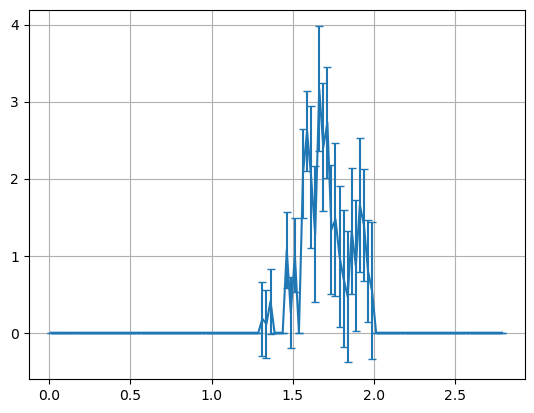

In [3]:
tomo = str(17)
plt.errorbar(np.array(data[tomo][0]), np.array(data[tomo][1]), yerr=np.array(data[tomo][2]), capsize=3)
plt.grid()

In [4]:
print(data[tomo][2])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.48125992054335937, 0.4417184945024973, 0.42262113738270507, 0.0, 0.0, 0.0, 0.48916130934955865, 0.4632544755941846, 0.48130232172278836, 0.0, 0.5727116867823902, 0.5201045889896335, 0.9240488966509656, 0.8816553744065828, 0.8113667869925839, 0.8282282235946803, 0.7165830074785006, 0.8320710646829926, 0.995609747182071, 0.9109182612222149, 0.8891612365638436, 0.8561707764377272, 0.8158900312241015, 0.8513282507582449, 0.8665599973027162, 0.721859385498053, 0.660292743858657, 0.8883524352255955, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [5]:
importlib.reload(spline)
import dill
save_splines = Path('splines')
save_splines.mkdir(exist_ok=True)

for tomo in data.keys():
    save_path = save_splines / f'spline_raw_{tomo}_photozbias.pkl'
    if Path(save_path).exists():
        continue
    arr = data[tomo][2].copy()
    data[tomo][2] = [1e-6 if v == 0 else v for v in arr]
    spl = spline.BayesianBSpline(zv=np.array(data[tomo][0]), n_knots=len(data[tomo][0]) // 2)
    spl.fit(np.array(data[tomo][1]), np.array(data[tomo][2]), target_accept=0.97, n_samples=2000, n_tune=500, prior_concentration=10)
    with open(save_path, 'wb') as f:
        dill.dump(spl, f)

Dirichlet alpha range: [0.180, 5.457]
Non-zero NNLS coefficients: 4 / 58


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 100 seconds.


Model fitting complete. Summary:              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]   0.576  0.193   0.292    0.996      0.004    0.004    2112.0   
coeffs[1]   0.414  0.193   0.000    0.698      0.004    0.004    2054.0   
coeffs[2]   0.009  0.003   0.004    0.016      0.000    0.000    9188.0   
coeffs[3]   0.000  0.000   0.000    0.000      0.000    0.000    6729.0   
coeffs[4]   0.000  0.000   0.000    0.000      0.000    0.000    3842.0   
coeffs[5]   0.000  0.000   0.000    0.000      0.000    0.000    4065.0   
coeffs[6]   0.000  0.000   0.000    0.000      0.000    0.000    2667.0   
coeffs[7]   0.000  0.000   0.000    0.000      0.000    0.000    2479.0   
coeffs[8]   0.000  0.000   0.000    0.000      0.000    0.000    2909.0   
coeffs[9]   0.000  0.000   0.000    0.000      0.000    0.000    2430.0   
coeffs[10]  0.000  0.000   0.000    0.000      0.000    0.000    2428.0   
coeffs[11]  0.000  0.000   0.000    0.000      0.000    0.000    26

/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/spline.py:374: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 900x800 with 3 Axes>,
 (<Axes: xlabel='Redshift (z)', ylabel='n(z)'>,
  <Axes: title={'center': 'B-spline Basis Functions (showing 58/58)'}, xlabel='Redshift (z)', ylabel='Basis amplitude'>,
  <Axes: title={'center': 'Posterior Coefficient Distribution'}, xlabel='Basis Function Index', ylabel='Coefficient Value'>))

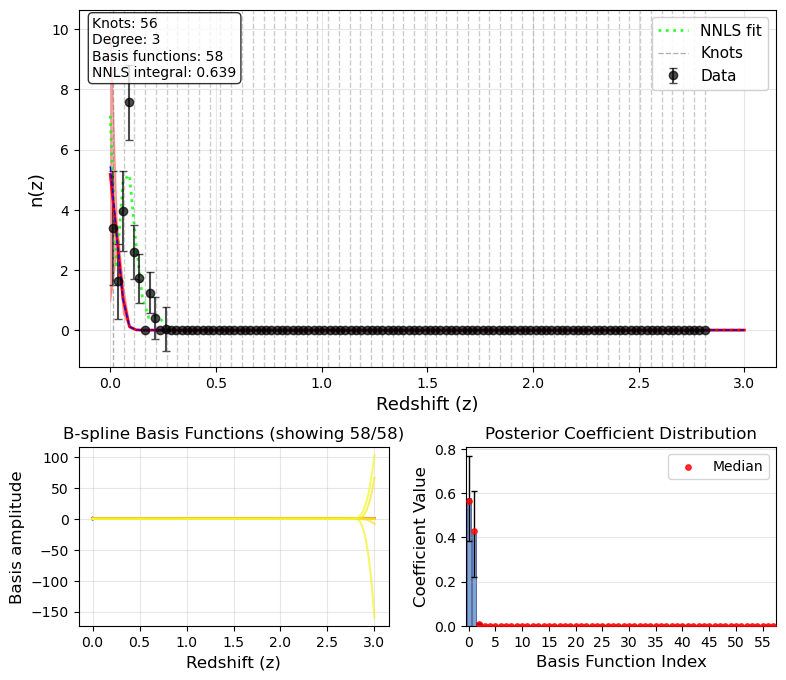

In [7]:
spl.plot_fit(z_eval=np.linspace(0, 3, 100))